In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
Hwannier, cell_map = hwannier("wannier"), np.loadtxt("wannier.map.txt");
force_matrix, cellph_map = phonon_force_matrix("totalE");
Pwannier = pwannier("wannier");
Heph, celleph_map = hephwannier("wannier"), np.loadtxt("wannier.mapeph.txt");
lattice_vectors = loadlattice("wannier.out");

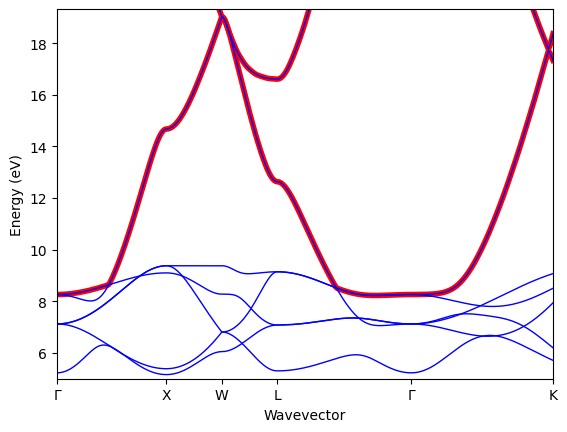

(5.0, 19.320093999999997)

In [4]:
# Plot of the wannierization scheme
plot_bands(Hwannier, cell_map, color="red", linewidth=4, whichbands=[6, 7])
plot_bands("totalE.bands.eigenvals", spin=1, color="blue", linewidth=1)
label_plots()
ylim(5, 0.71/eV)

In [56]:
E, DOS = density_of_states(Hwannier, cell_map, Val(3), mesh=5, monte_carlo=true, num_blocks=1000, histogram_width=10)

([4.1606023795095135, 4.260470141943678, 4.360337904377843, 4.460205666812008, 4.560073429246172, 4.659941191680337, 4.759808954114502, 4.859676716548666, 4.959544478982831, 5.059412241416996  …  30.925162711865656, 31.02503047429982, 31.124898236733987, 31.224765999168152, 31.324633761602314, 31.42450152403648, 31.524369286470645, 31.62423704890481, 31.724104811338975, 31.82397257377314], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [57]:
Es, μs = find_chemical_potential(E, DOS*2)

([4.260470141943678, 4.360337904377843, 4.460205666812008, 4.560073429246172, 4.659941191680337, 4.759808954114502, 4.859676716548666, 4.959544478982831, 5.059412241416996, 5.159280003851161  …  30.925162711865656, 31.02503047429982, 31.124898236733987, 31.224765999168152, 31.324633761602314, 31.42450152403648, 31.524369286470645, 31.62423704890481, 31.724104811338975, 31.82397257377314], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  13.981486740783058, 13.981486740783058, 13.981486740783058, 13.981486740783058, 13.981486740783058, 13.981486740783058, 13.981486740783058, 13.981486740783058, 13.981486740783058, 13.981486740783058])

In [109]:
μ = Es[argmin(abs.(μs .- 11))]
dos_μ = smooth(DOS,win_len=10 )[argmin(abs.(E .- μ))]
println("Fermi energy is: $(μ)")
println("DOS at Fermi energy is: $(dos_μ)")

Fermi energy is: 13.048833236150173
DOS at Fermi energy is: 0.12837899068314004


In [5]:
tau_histogram_inv = zeros(100)
tau_gaussian_inv = zeros(100)
tau_lorentzian_inv = zeros(100)
N = 100
for i in 1:N
    tau_histogram_inv += 1 ./ np.loadtxt("boltzmann/histogram-$i.txt") 
    tau_gaussian_inv += 1 ./ np.loadtxt("boltzmann/gaussian-$i.txt") 
    tau_lorentzian_inv += 1 ./ np.loadtxt("boltzmann/lorentzian-$i.txt") 
end
tau_histogram_inv *= 1/N;
tau_gaussian_inv *= 1/N;
tau_lorentzian_inv *= 1/N;
tau_lorentzian = 1 ./ tau_lorentzian_inv;
tau_gaussian = 1 ./ tau_gaussian_inv;
tau_histogram = 1 ./ tau_histogram_inv;
fw_x, fw_y = [col for col in eachcol(np.loadtxt("fwdir/tauAC.dat"))];

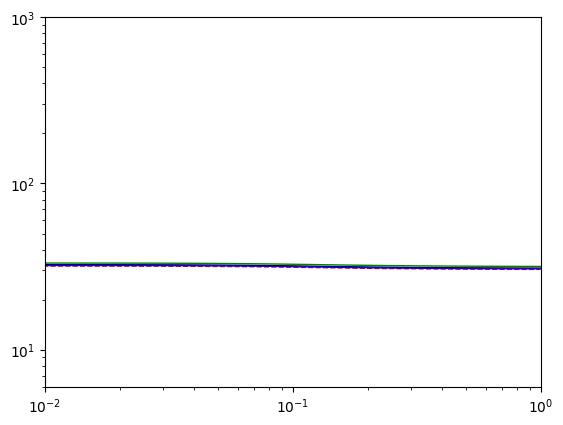

(6, 1000)

In [6]:
linewidth=1
loglog(fw_x, fw_y, color="red", linestyle="dashed", linewidth=linewidth)
loglog(collect(0.01:0.01:1), tau_histogram, color="black", linewidth=linewidth)
loglog(collect(0.01:0.01:1), tau_gaussian, color="blue", linewidth=linewidth)
loglog(collect(0.01:0.01:1), tau_lorentzian, color="green", linewidth=linewidth)

xlim(0.01, 1)
ylim(6, 1000)
#ylim(20, 40)

In [10]:
tau_allen_inv = zeros(100)
N = 200
idx = 1
for i in idx:idx+N-1
    tau_allen_inv += 1 ./ np.loadtxt("boltzmann/boltzmann-$i.txt")
end
tau_allen = N ./ tau_allen_inv;

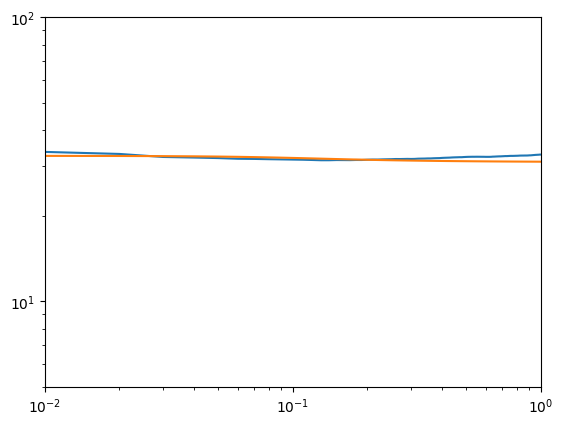

(0.01, 1)

In [11]:
loglog(collect(0.01:0.01:1), tau_allen)
loglog(collect(0.01:0.01:1), tau_histogram)
ylim(5, 100)
xlim(0.01, 1)

In [16]:
np.savetxt("tau.txt", hcat([tau_histogram, tau_gaussian, tau_lorentzian, tau_allen]...), header="hist, gauss, lorentz, allen")

In [19]:
tau_histogram, tau_gaussian, tau_lorentzian, tau_allen = [col for col in eachcol(np.loadtxt("tau.txt"))];

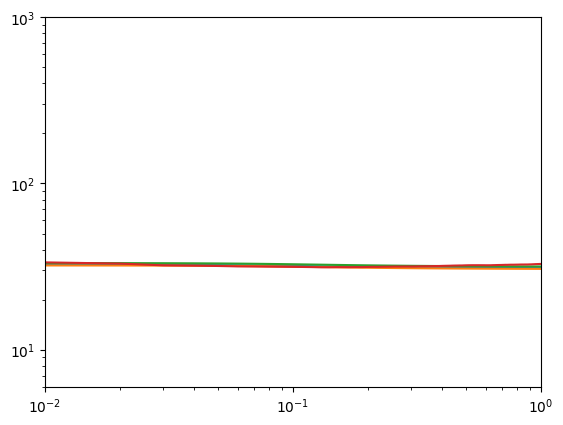

(0.01, 1)

In [24]:
omegas = collect(0.01:0.01:1)
loglog(omegas, tau_histogram)
loglog(omegas, tau_gaussian)
loglog(omegas, tau_lorentzian)
loglog(omegas, tau_allen)

ylim(6, 1000)
xlim(0.01, 1)